# Harness Results Analysis

This notebook analyzes the latest harness run and reproduces key plots/metrics from `analyze_harness_results.py` in an interactive format.

Run analyzed in this notebook:
- `harness_20260327T105404Z.jsonl`
- `ANALYSIS_harness_20260327T105404Z.md`
- `BEST_CONFIG_20260327T105404Z.json`

In [ ]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TRAITS = ["O", "C", "E", "A", "N"]
TRAIT_LABELS = {
    "O": "Openness",
    "C": "Conscientiousness",
    "E": "Extraversion",
    "A": "Agreeableness",
    "N": "Neuroticism",
}

root = Path.cwd()
if root.name != "offline_nv_detection":
    root = Path("/Users/huaduojiejia/MyProject/hslu/2026/thesis project/big5loop/evaluation_data/pandora/offline_nv_detection")

results_dir = root / "results"
run_id = "20260327T105404Z"
jsonl_path = results_dir / f"harness_{run_id}.jsonl"
analysis_path = results_dir / f"ANALYSIS_harness_{run_id}.md"
best_cfg_path = results_dir / f"BEST_CONFIG_{run_id}.json"

jsonl_path, analysis_path, best_cfg_path

(PosixPath('/Users/huaduojiejia/MyProject/hslu/2026/thesis project/big5loop/evaluation_data/pandora/offline_nv_detection/results/harness_20260327T105404Z.jsonl'),
 PosixPath('/Users/huaduojiejia/MyProject/hslu/2026/thesis project/big5loop/evaluation_data/pandora/offline_nv_detection/results/ANALYSIS_harness_20260327T105404Z.md'),
 PosixPath('/Users/huaduojiejia/MyProject/hslu/2026/thesis project/big5loop/evaluation_data/pandora/offline_nv_detection/results/BEST_CONFIG_20260327T105404Z.json'))

In [ ]:
rows = []
with open(jsonl_path, encoding="utf-8") as f:
    for line in f:
        rows.append(json.loads(line))

df = pd.DataFrame(rows)

for t in TRAITS:
    df[f"gt_{t}"] = df["ground_truth_ocean"].apply(lambda x: float((x or {}).get(t, np.nan)))
    df[f"pr_{t}"] = df["predicted_ocean"].apply(
        lambda x: float((x or {}).get(t, np.nan)) if x else np.nan
    )

df["has_prediction"] = df["predicted_ocean"].notna()

print(f"Loaded {len(df)} rows")
print(f"Valid predictions: {df['has_prediction'].sum()} ({df['has_prediction'].mean():.1%})")
print(f"Models: {df['model'].nunique()}, prompt sets: {df['prompt_set'].nunique()}, shots: {df['n_shots'].nunique()}")
df.head(3)

Loaded 160 rows
Valid predictions: 90 (56.2%)
Models: 2, prompt sets: 2, shots: 2


,sample_id,model,prompt_set,n_shots,ground_truth_ocean,predicted_ocean,n_valid_variants,n_total_variants,variant_details,gt_O,pr_O,gt_C,pr_C,gt_E,pr_E,gt_A,pr_A,gt_N,pr_N,has_prediction
0,2818053,meta/llama-3.1-70b-instruct,workflow_current,5,"{'O': -0.88, 'C': -0.1, 'E': -0.64, 'A': 0.78,...","{'O': 0.0, 'C': 0.46666666666666673, 'E': 0.39...",3,3,"[{'variant': 'pandora_calibrated_v2', 'error':...",-0.88,0.000000,-0.1,0.466667,-0.64,0.400000,0.78,-0.2,0.86,0.266667,True
1,2818053,meta/llama-3.1-70b-instruct,workflow_current,20,"{'O': -0.88, 'C': -0.1, 'E': -0.64, 'A': 0.78,...","{'O': 0.3666666666666667, 'C': 0.5333333333333...",3,3,"[{'variant': 'pandora_calibrated_v2', 'error':...",-0.88,0.366667,-0.1,0.533333,-0.64,0.333333,0.78,0.0,0.86,-0.033333,True
2,2818053,meta/llama-3.1-70b-instruct,minimal_instruction_v1,5,"{'O': -0.88, 'C': -0.1, 'E': -0.64, 'A': 0.78,...","{'O': 0.1, 'C': 0.6000000000000001, 'E': 0.3, ...",2,3,"[{'variant': 'minimal_main', 'error': None, 'o...",-0.88,0.100000,-0.1,0.600000,-0.64,0.300000,0.78,0.7,0.86,0.050000,True


In [ ]:
def group_metrics(group: pd.DataFrame) -> dict:
    ok = group[group["has_prediction"]].copy()
    n = len(ok)
    total = len(group)
    if n < 3:
        return {
            "n": n,
            "total": total,
            "coverage": n / total if total else 0.0,
            "macro_pearson": np.nan,
            "macro_mae": np.nan,
        }

    pears, maes = [], []
    for t in TRAITS:
        gt = ok[f"gt_{t}"].values
        pr = ok[f"pr_{t}"].values
        mask = ~(np.isnan(gt) | np.isnan(pr))
        if mask.sum() < 3:
            continue
        if np.std(gt[mask]) > 0 and np.std(pr[mask]) > 0:
            pear = float(np.corrcoef(gt[mask], pr[mask])[0, 1])
        else:
            pear = 0.0
        mae = float(np.mean(np.abs(pr[mask] - gt[mask])))
        pears.append(pear)
        maes.append(mae)

    return {
        "n": n,
        "total": total,
        "coverage": n / total if total else 0.0,
        "macro_pearson": float(np.mean(pears)) if pears else np.nan,
        "macro_mae": float(np.mean(maes)) if maes else np.nan,
    }


def composite(m: dict) -> float:
    r = 0.0 if np.isnan(m["macro_pearson"]) else m["macro_pearson"]
    c = m["coverage"]
    mae = 1.0 if np.isnan(m["macro_mae"]) else m["macro_mae"]
    return 0.5 * r + 0.3 * c + 0.2 * (1.0 - mae)

summary_rows = []
for (model, prompt_set, n_shots), g in df.groupby(["model", "prompt_set", "n_shots"]):
    m = group_metrics(g)
    m.update({"model": model, "prompt_set": prompt_set, "n_shots": n_shots, "composite": composite(m)})
    summary_rows.append(m)

summary = pd.DataFrame(summary_rows).sort_values("composite", ascending=False)
summary.head(12)

,n,total,coverage,macro_pearson,macro_mae,model,prompt_set,n_shots,composite
2,20,20,1.00,0.156339,0.610133,meta/llama-3.1-70b-instruct,workflow_current,5,0.456143
1,19,20,0.95,0.157262,0.568965,meta/llama-3.1-70b-instruct,minimal_instruction_v1,20,0.449838
0,20,20,1.00,0.116748,0.594500,meta/llama-3.1-70b-instruct,minimal_instruction_v1,5,0.439474
3,20,20,1.00,0.055762,0.601167,meta/llama-3.1-70b-instruct,workflow_current,20,0.407648
4,4,20,0.20,0.445106,0.472000,meta/llama-3.3-70b-instruct,minimal_instruction_v1,5,0.388153
6,4,20,0.20,0.058654,0.634000,meta/llama-3.3-70b-instruct,workflow_current,5,0.162527
7,2,20,0.10,NaN,NaN,meta/llama-3.3-70b-instruct,workflow_current,20,0.030000
5,1,20,0.05,NaN,NaN,meta/llama-3.3-70b-instruct,minimal_instruction_v1,20,0.015000


In [ ]:
if best_cfg_path.exists():
    best_cfg = json.loads(best_cfg_path.read_text(encoding="utf-8"))
    print("Winner from BEST_CONFIG:")
    print(json.dumps(best_cfg, indent=2))
else:
    print("BEST_CONFIG file not found")

print("\nTop row from recomputed summary:")
print(summary.iloc[0][["model", "prompt_set", "n_shots", "composite", "macro_pearson", "macro_mae", "coverage"]])

Winner from BEST_CONFIG:
{
  "run_id": "20260327T105404Z",
  "selected_at": "2026-03-27T12:00:34.941572+00:00",
  "model": "meta/llama-3.1-70b-instruct",
  "prompt_set": "workflow_current",
  "n_shots": 5,
  "composite_score": 0.45614302059874823,
  "metrics": {
    "macro_pearson": 0.1563393745308298,
    "macro_spearman": 0.18678839045919504,
    "macro_mae": 0.6101333333333332,
    "macro_bias": 0.13186666666666663,
    "coverage": 1.0,
    "bootstrap_ci_95": [
      -0.029076748821060757,
      0.35553257649821396
    ],
    "per_trait": {
      "O": {
        "pearson": 0.32453685512677444,
        "spearman": 0.5226903719829892,
        "mae": 0.5273333333333332,
        "bias": 0.33999999999999997,
        "gt_mean": -0.295,
        "gt_std": 0.5786326895999605,
        "pred_mean": 0.045,
        "pred_std": 0.2562151416884048
      },
      "C": {
        "pearson": 0.19894569205912807,
        "spearman": 0.23759137789294665,
        "mae": 0.5246666666666666,
        "bias":

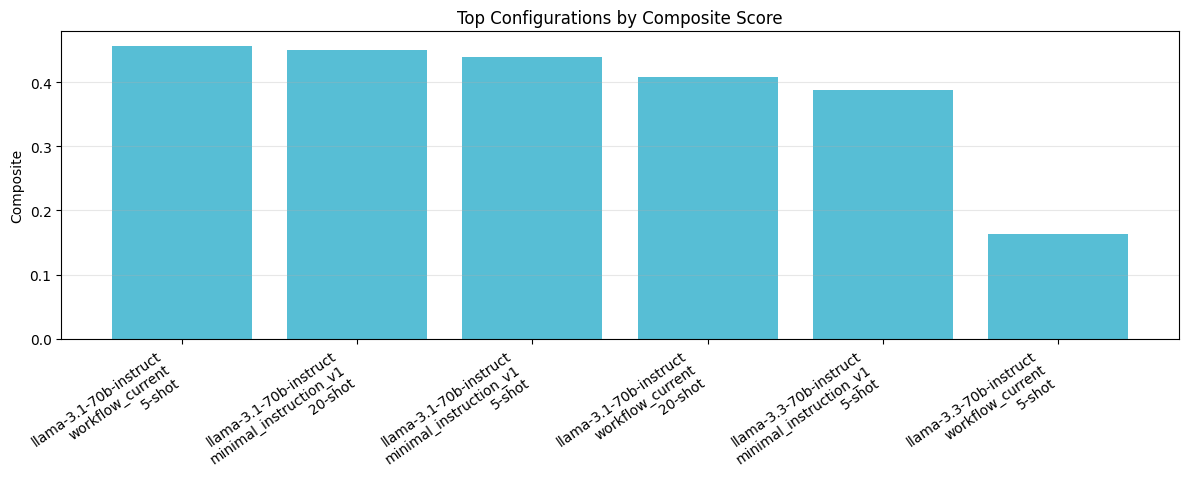

In [ ]:
plot_df = summary.copy()
plot_df = plot_df[np.isfinite(plot_df["macro_pearson"])].copy()
plot_df["model_short"] = plot_df["model"].str.split("/").str[-1]
plot_df["config"] = plot_df["model_short"] + "\n" + plot_df["prompt_set"] + "\n" + plot_df["n_shots"].astype(str) + "-shot"
plot_df = plot_df.sort_values("composite", ascending=False).head(12)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(plot_df["config"], plot_df["composite"], color="#45B7D1", alpha=0.9)
ax.set_title("Top Configurations by Composite Score")
ax.set_ylabel("Composite")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

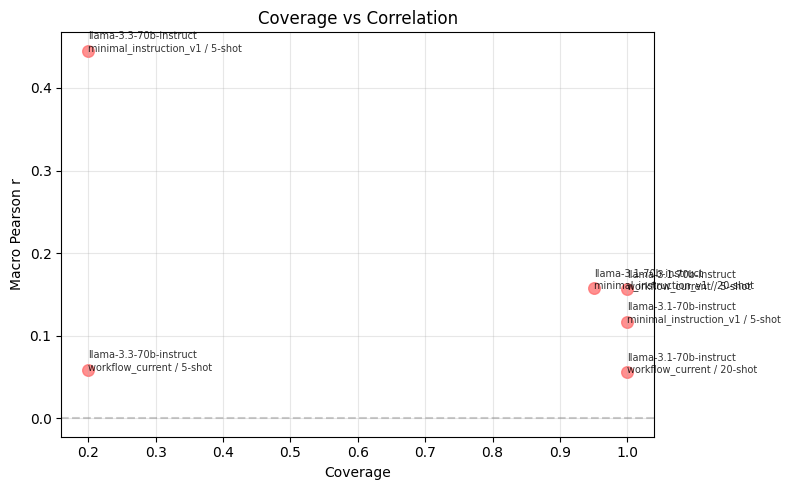

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(summary["coverage"], summary["macro_pearson"], s=70, alpha=0.75, color="#FF6B6B")
ax.axhline(0, color="gray", linestyle="--", alpha=0.4)
ax.set_xlabel("Coverage")
ax.set_ylabel("Macro Pearson r")
ax.set_title("Coverage vs Correlation")
ax.grid(alpha=0.3)
for _, r in summary.head(8).iterrows():
    ax.annotate(
        f"{r['model'].split('/')[-1]}\n{r['prompt_set']} / {int(r['n_shots'])}-shot",
        (r["coverage"], r["macro_pearson"]),
        fontsize=7,
        alpha=0.8,
    )
plt.tight_layout()
plt.show()

In [ ]:
analysis_text = analysis_path.read_text(encoding="utf-8") if analysis_path.exists() else "No analysis markdown found"
print(analysis_text[:3500])

# 🔬 Prompt & Model Harness Engineering Report

- **Run ID**: `20260327T105404Z`
- **Samples**: 20
- **Models**: `meta/llama-3.1-70b-instruct`, `meta/llama-3.3-70b-instruct`
- **Prompt sets**: `workflow_current`, `minimal_instruction_v1`
- **Few-shot counts**: [0, 5, 10, 20]
- **Total configs**: 8
- **Retries**: 3, backoff: 1.5s

## 🏆 Leaderboard (Top 20)

| Rank | Model | Prompt Set | Shots | n | Coverage | Macro r | 95% CI | Macro ρ | Macro MAE | Composite |
|------|-------|------------|-------|---|----------|---------|--------|---------|-----------|-----------|
| 1 | `meta/llama-3.1-70b-instruct` | `workflow_current` | 5 | 20 | 100% | 0.1563 | [-0.029, 0.356] | 0.1868 | 0.6101 | 0.4561 |
| 2 | `meta/llama-3.1-70b-instruct` | `minimal_instruction_v1` | 20 | 19 | 95% | 0.1573 | [-0.051, 0.374] | 0.1455 | 0.5690 | 0.4498 |
| 3 | `meta/llama-3.1-70b-instruct` | `minimal_instruction_v1` | 5 | 20 | 100% | 0.1167 | [-0.111, 0.356] | 0.1328 | 0.5945 | 0.4395 |
| 4 | `meta/llama-3.1-70b-instr

In [9]:
export_cols = [
    "model",
    "prompt_set",
    "n_shots",
    "n",
    "total",
    "coverage",
    "macro_pearson",
    "macro_mae",
    "composite",
]

out_csv = results_dir / f"top_configs_{run_id}.csv"
(
    summary[export_cols]
    .sort_values("composite", ascending=False)
    .to_csv(out_csv, index=False)
)

print(f"Saved: {out_csv}")
summary[export_cols].sort_values("composite", ascending=False).head(15)

Saved: /Users/huaduojiejia/MyProject/hslu/2026/thesis project/big5loop/evaluation_data/pandora/offline_nv_detection/results/top_configs_20260327T105404Z.csv


,model,prompt_set,n_shots,n,total,coverage,macro_pearson,macro_mae,composite
2,meta/llama-3.1-70b-instruct,workflow_current,5,20,20,1.00,0.156339,0.610133,0.456143
1,meta/llama-3.1-70b-instruct,minimal_instruction_v1,20,19,20,0.95,0.157262,0.568965,0.449838
0,meta/llama-3.1-70b-instruct,minimal_instruction_v1,5,20,20,1.00,0.116748,0.594500,0.439474
3,meta/llama-3.1-70b-instruct,workflow_current,20,20,20,1.00,0.055762,0.601167,0.407648
4,meta/llama-3.3-70b-instruct,minimal_instruction_v1,5,4,20,0.20,0.445106,0.472000,0.388153
6,meta/llama-3.3-70b-instruct,workflow_current,5,4,20,0.20,0.058654,0.634000,0.162527
7,meta/llama-3.3-70b-instruct,workflow_current,20,2,20,0.10,NaN,NaN,0.030000
5,meta/llama-3.3-70b-instruct,minimal_instruction_v1,20,1,20,0.05,NaN,NaN,0.015000
